# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab3 - Semantic Segmentation with U-Net

2025 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

In [1]:
# !pip install -q segmentation-models-pytorch albumentations==1.3.0 torchmetrics


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import os
from tqdm import tqdm


c:\Users\enric\OneDrive\Documentos\Master\CVDL\Labs\cvdl-labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)
if device.type == "cpu":
    print("WARNING: You are using CPU. Consider switching to GPU in Runtime > Change runtime type.")


Device in use: cuda


## Load Dataset and Prepare Train/Test Splits

In [4]:
dataset = OxfordIIITPet(root="./data", download=True, target_types="segmentation")

def convert_mask(mask):
    mask = np.array(mask)
    mask = (mask > 1).astype(np.uint8)
    return mask

class PetSegmentationDataset(Dataset):
    def __init__(self, base_ds, indices, transform=None):
        self.base_ds = base_ds
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        image, mask = self.base_ds[self.indices[idx]]
        image = np.array(image)
        mask = convert_mask(mask)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        return image, mask

    def __len__(self):
        return len(self.indices)

# Create train/test splits
indices = list(range(len(dataset)))
np.random.seed(42)
np.random.shuffle(indices)
train_indices = indices[:200]
test_indices = indices[200:250]



# Train transforms
train_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

# Train transforms
test_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

train_ds = PetSegmentationDataset(dataset, train_indices, transform=train_transform)
test_ds = PetSegmentationDataset(dataset, test_indices, transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)


100%|██████████| 791918971/791918971 [03:49<00:00, 3455739.54it/s]


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100%|██████████| 19173078/19173078 [00:04<00:00, 4043162.70it/s]


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet


## Visualize Original images and Augmentations (Outside of Training)

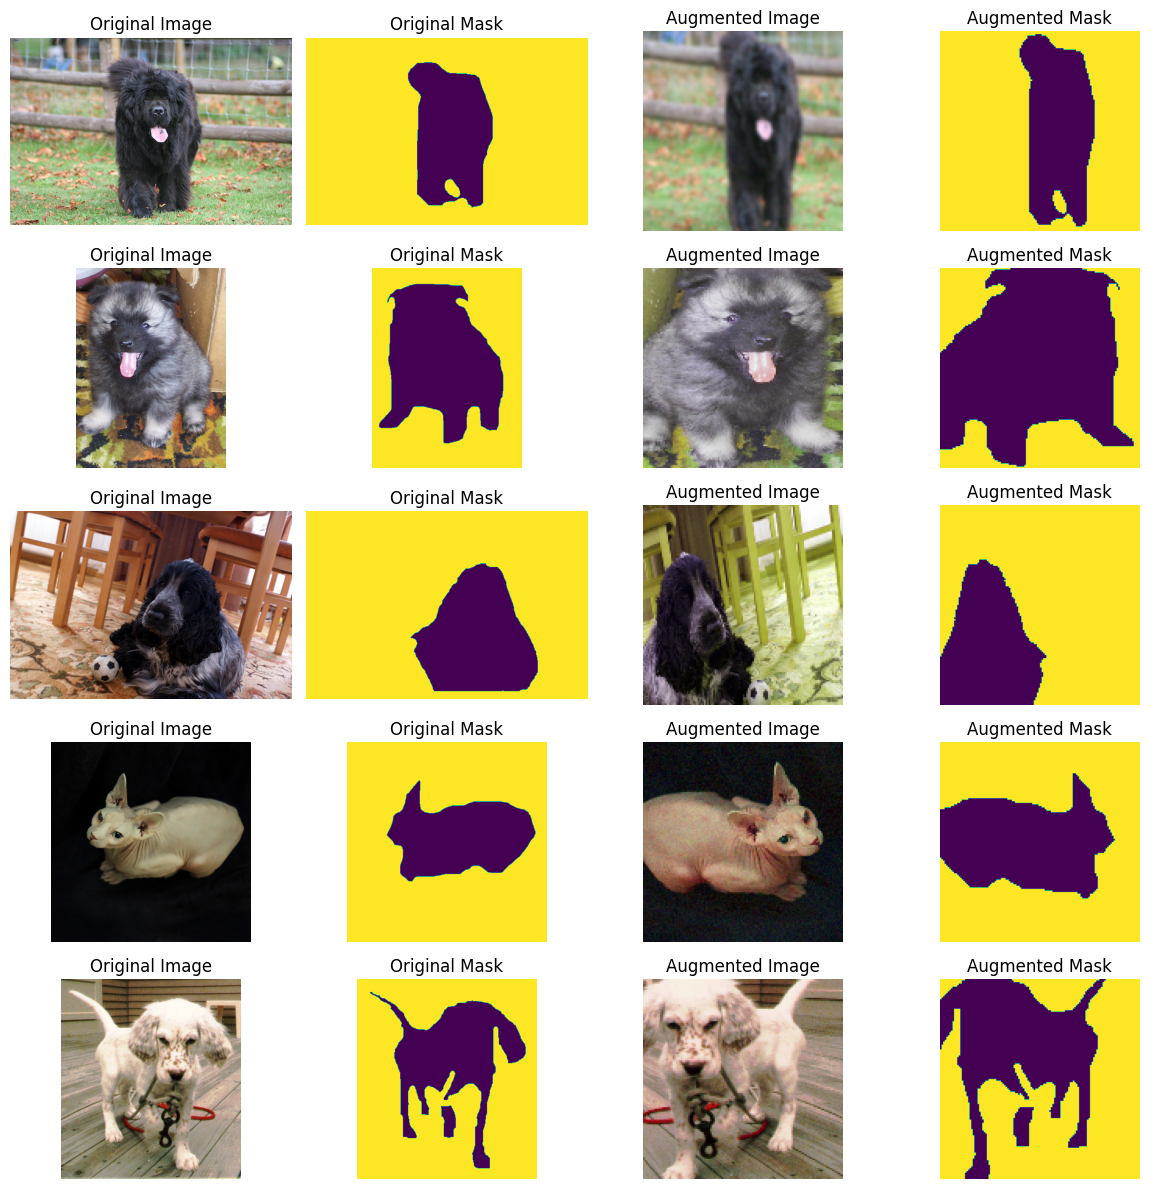

In [5]:
# Visualize with a slightly more augmented transform
# This transformation pipeline includes additional augmentations that are commonly used
# to increase dataset diversity by altering color, intensity, and sharpness. These are NOT
# part of the actual training setup, but are shown here to help you understand what
# advanced augmentations do.

# - Resize(160, 160): scales all images to a slightly larger size, preparing them for cropping.
# - RandomCrop(128, 128): randomly crops a 128x128 region from the resized image.
#   This simulates zooming into different parts of the image during training and introduces
#   positional variability. The model learns to recognize objects regardless of their exact position.
# - HorizontalFlip: flips the image left to right with 50% probability.
# - RandomBrightnessContrast: randomly changes brightness and contrast of the image.
# - HueSaturationValue: randomly changes hue, saturation, and value (HSV space).
# - GaussNoise: adds random Gaussian noise to the image.
# - GaussianBlur: slightly blurs the image to simulate low focus or motion.

# These augmentations are often useful in real-world settings where lighting and noise vary a lot.
# Try experimenting by adding or removing different transformations and seeing their effects.

sample_transform = A.Compose([
    A.Resize(160, 160),
    A.RandomCrop(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.5),
    A.GaussNoise(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

# Visualize original vs augmented image/mask pairs

aug_ds = PetSegmentationDataset(dataset, train_indices, transform=sample_transform)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
def denormalize(img):
    img = img.permute(1, 2, 0).numpy()
    return (img * std + mean).clip(0, 1)

# Show original and transformed side by side
fig, axs = plt.subplots(5, 4, figsize=(12, 12))

for i in range(5):
    image, mask = dataset[train_indices[i]]
    orig_image = np.array(image)
    orig_mask = convert_mask(mask)

    augmented = sample_transform(image=orig_image, mask=orig_mask)
    aug_image = augmented['image']
    aug_mask = augmented['mask']

    axs[i, 0].imshow(orig_image)
    axs[i, 0].set_title("Original Image")
    axs[i, 1].imshow(orig_mask)
    axs[i, 1].set_title("Original Mask")
    axs[i, 2].imshow(denormalize(aug_image))
    axs[i, 2].set_title("Augmented Image")
    axs[i, 3].imshow(aug_mask)
    axs[i, 3].set_title("Augmented Mask")

    for j in range(4):
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

## Define U-Net Model and Training Setup

In [6]:
# Create the segmentation model: U-Net with ResNet34 encoder
import segmentation_models_pytorch as smp

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", classes=2, activation=None)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.to(device)


c:\Users\enric\OneDrive\Documentos\Master\CVDL\Labs\cvdl-labs\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\enric\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## Train the Model

In [7]:
# Simple training loop over 10 epochs (you can increase this number!)
for epoch in range(10):
    model.train()
    running_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_loader):.4f}")


Epoch 1 | Loss: 0.4484
Epoch 2 | Loss: 0.3254
Epoch 3 | Loss: 0.2809
Epoch 4 | Loss: 0.2653
Epoch 5 | Loss: 0.2164
Epoch 6 | Loss: 0.1745
Epoch 7 | Loss: 0.1728
Epoch 8 | Loss: 0.1826
Epoch 9 | Loss: 0.1766
Epoch 10 | Loss: 0.1492


## Evaluate on Test Set (IoU and Dice)

Test mIoU: 0.73592209815979
Test Dice: 0.8316650390625


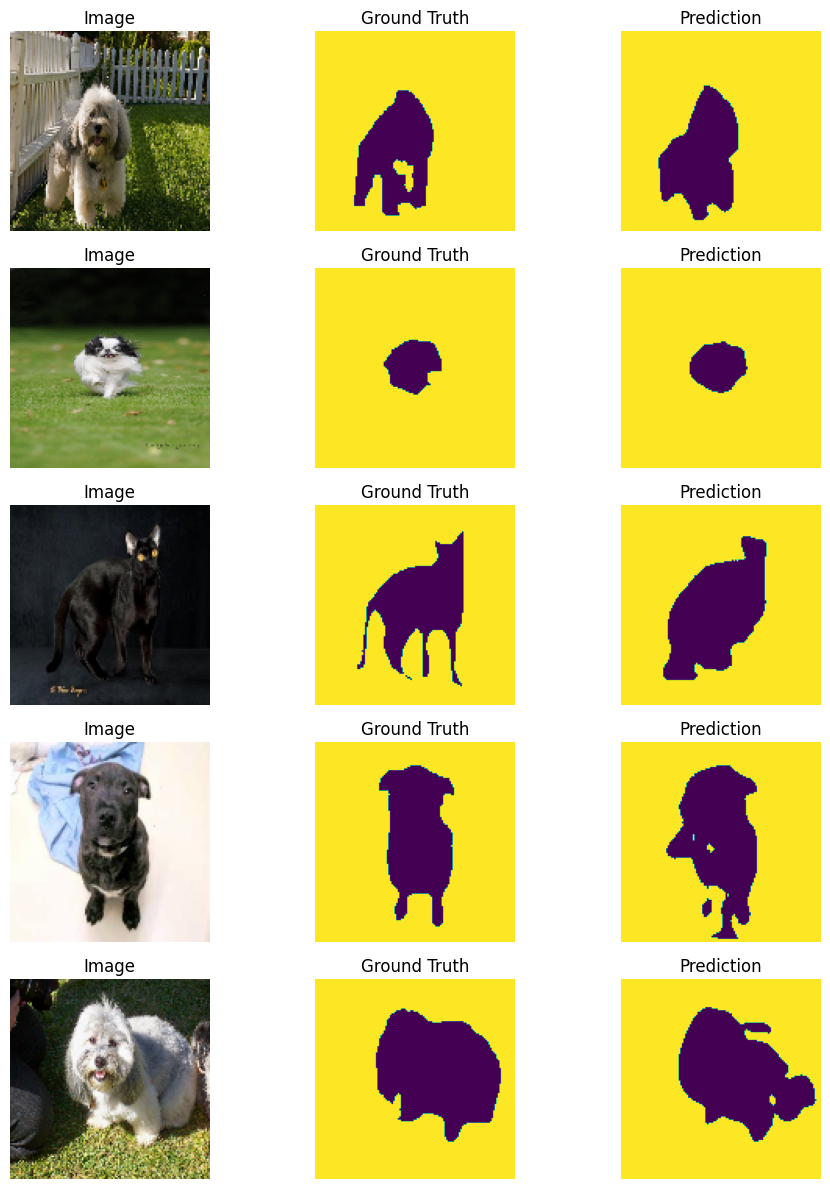

In [8]:
# Evaluate and visualize predictions on a batch of validation data
from torchmetrics import JaccardIndex
from torchmetrics.segmentation import DiceScore

iou = JaccardIndex(task="multiclass", num_classes=2, average="macro").to(device)
dice = DiceScore(num_classes=2, average="macro", input_format="index").to(device)

# Evaluation loop
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        iou.update(preds, masks)
        dice.update(preds, masks)

# Compute and print metrics
print("Test mIoU:", iou.compute().item())
print("Test Dice:", dice.compute().item())


# Visualize predictions from one test batch
# Denormalization helper (already defined earlier)
def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    return (img * std + mean).clip(0, 1)

# Take a batch from the test set
images, masks = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
preds = torch.argmax(outputs, dim=1).cpu()

# Plot the first 5 examples
fig, axs = plt.subplots(5, 3, figsize=(10, 12))
for i in range(5):
    axs[i, 0].imshow(denormalize(images[i]))
    axs[i, 0].set_title("Image")
    axs[i, 1].imshow(masks[i])
    axs[i, 1].set_title("Ground Truth")
    axs[i, 2].imshow(preds[i])
    axs[i, 2].set_title("Prediction")
    for j in range(3):
        axs[i, j].axis("off")
plt.tight_layout()
plt.show()


## Tasks

1. Change the encoder from `'resnet34'` to `'efficientnet-b0'`.

2. Replace the loss function with `DiceLoss(mode='binary')`.
   - Note: `DiceLoss` expects **float binary masks** with shape `[B, 1, H, W]`, and model outputs filtered to the foreground channel using `outputs[:, 1:2, :, :]`.
   - Use the following line inside your training loop:
     ```python
     loss = loss_fn(outputs[:, 1:2, :, :], masks.unsqueeze(1).float())
     ```

3. Modify the training transform to include any of the random transformations shown before (section *Visualize Original Images and Augmentations*).

4. Retrain the model with the new setup (you can also change the number of epochs or other hyperparameters in this and in the original experiment)

5. Re-evaluate the model on the test set using IoU and Dice.

